In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets  import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection  import train_test_split

In [17]:
x,y=make_classification(
    n_features=10,
    n_samples=1000,
    n_informative=4,
    n_redundant=6,
    n_repeated=0,
    n_classes=2,
    random_state=42
)

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.25,random_state=42)

# logistic regression classifier

In [18]:
model=LogisticRegression()
model.fit(x_train,y_train)
from sklearn.metrics import classification_report

y_pred=model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.66      0.69      0.67       122
           1       0.69      0.66      0.68       128

    accuracy                           0.68       250
   macro avg       0.68      0.68      0.68       250
weighted avg       0.68      0.68      0.68       250



In [19]:
probability=model.predict_proba(x_test)[:,1]
y_pred=(probability>0.4).astype(int)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.57      0.65       122
           1       0.67      0.82      0.74       128

    accuracy                           0.70       250
   macro avg       0.71      0.70      0.69       250
weighted avg       0.71      0.70      0.70       250



# Increasing recall

In [22]:
from sklearn.metrics import roc_curve

fpr,tpr,threshold=roc_curve(y_test,probability)

In [23]:
fpr[:5],tpr[:5],threshold[:5]

(array([0.        , 0.        , 0.        , 0.00819672, 0.00819672]),
 array([0.       , 0.0078125, 0.265625 , 0.265625 , 0.2890625]),
 array([       inf, 0.97928246, 0.80890214, 0.80840719, 0.80207033]))

In [24]:
tpr

array([0.       , 0.0078125, 0.265625 , 0.265625 , 0.2890625, 0.2890625,
       0.296875 , 0.296875 , 0.34375  , 0.34375  , 0.3515625, 0.3515625,
       0.375    , 0.375    , 0.3984375, 0.3984375, 0.4296875, 0.4296875,
       0.4375   , 0.4375   , 0.4609375, 0.4609375, 0.46875  , 0.46875  ,
       0.4765625, 0.4765625, 0.484375 , 0.484375 , 0.4921875, 0.4921875,
       0.5078125, 0.5078125, 0.515625 , 0.515625 , 0.5390625, 0.5390625,
       0.5546875, 0.5546875, 0.5859375, 0.5859375, 0.625    , 0.625    ,
       0.640625 , 0.640625 , 0.6484375, 0.6484375, 0.65625  , 0.65625  ,
       0.71875  , 0.71875  , 0.75     , 0.75     , 0.7578125, 0.7578125,
       0.765625 , 0.765625 , 0.7734375, 0.7734375, 0.7890625, 0.7890625,
       0.796875 , 0.796875 , 0.84375  , 0.84375  , 0.8515625, 0.8515625,
       0.859375 , 0.859375 , 0.8671875, 0.8671875, 0.875    , 0.875    ,
       0.8828125, 0.8828125, 0.890625 , 0.890625 , 0.90625  , 0.90625  ,
       0.9140625, 0.9140625, 0.921875 , 0.921875 , 

In [26]:
desired_recall=0.9

closest_index=np.argmin(abs(tpr-desired_recall))
closest_index

np.int64(76)

In [ ]:
threshold[closest_index]

np.float64(0.26349585272229664)

In [28]:
probability=model.predict_proba(x_test)[:,1]
y_pred=(probability>0.26349585272229664).astype(int)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.73      0.30      0.42       122
           1       0.57      0.90      0.70       128

    accuracy                           0.60       250
   macro avg       0.65      0.60      0.56       250
weighted avg       0.65      0.60      0.56       250



## Calculating AUC

In [29]:
from sklearn.metrics import auc

area=auc(fpr,tpr)
area

0.764856557377049

## plotting ROC

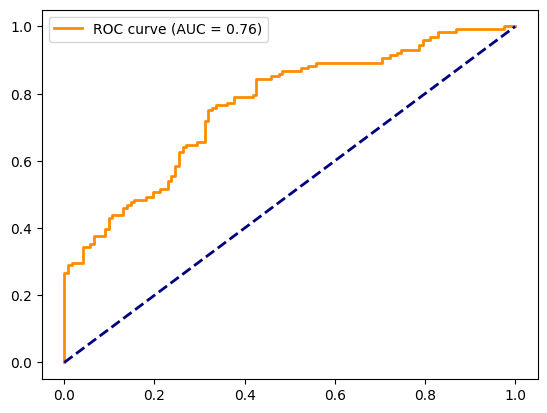

In [31]:
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {area:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.legend()
plt.show()

# XGBoost classifier

In [32]:
from xgboost import XGBClassifier

model=XGBClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92       122
           1       0.94      0.89      0.92       128

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250



## calculating AUC for XGBoost classifier

In [34]:
y_score=model.predict_proba(x_test)[:,1]
fpr_xgb,tpr_xgb,threshold_xgb=roc_curve(y_test,y_score)
area2=auc(fpr_xgb,tpr_xgb)

In [35]:
area2

0.9505635245901639

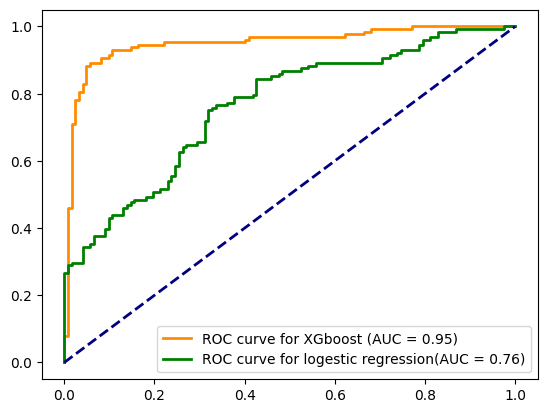

In [40]:
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2, label=f'ROC curve for XGboost (AUC = {area2:.2f})')
plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC curve for logestic regression(AUC = {area:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.legend()
plt.show()

## threshold calculation

In [46]:
desired_recall=0.92

closest_index=np.argmin(abs(tpr_xgb-desired_recall))
closest_index

np.int64(22)

In [47]:
threshold_xgb[closest_index],fpr_xgb[closest_index]

(np.float64(0.32361674308776855), np.float64(0.09836065573770492))